In [25]:
import pandas as pd 
ap_data=pd.read_csv("../data/appl_day6_trading_decision.csv",index_col='Date',parse_dates=True)
ap_data.head()

,Close,High,Low,Open,Volume,Returns,Rolling Mean,Rolling Volatility,Cumulative Return,Fear_Greed,Risk_Adjustment_Returns,Fear_Signal,Investor_Bias,Recommendataion,sharpe_Rato,Rolling_Sharpe,Performance,Recommendation
Date,,,,,,,,,,,,,,,,,,
2019-02-14,40.736500,40.846210,40.397824,40.476531,87342800,0.003643,37.934863,NaN,1.003643,Greed,NaN,Greed,Neutral,Hold,NaN,NaN,Poor,Hold
2019-02-15,40.645874,40.951159,40.486077,40.843833,98507200,-0.002225,38.164123,NaN,1.001410,Greed,NaN,Greed,Neutral,Hold,NaN,NaN,Poor,Hold
2019-02-19,40.767506,40.889145,40.424063,40.476534,75891200,0.002992,38.349386,NaN,1.004407,Greed,NaN,Greed,Neutral,Hold,NaN,NaN,Poor,Hold
2019-02-20,41.029861,41.337534,40.781819,40.829519,104457600,0.006435,38.546007,NaN,1.010871,Greed,NaN,Greed,Neutral,Hold,NaN,NaN,Poor,Hold
2019-02-21,40.798512,41.110951,40.617250,40.975006,68998800,-0.005639,38.712592,NaN,1.005171,Greed,NaN,Greed,Neutral,Hold,NaN,NaN,Poor,Hold


In [26]:
ap_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Rolling Mean',
       'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation'],
      dtype='object')

In [40]:
ap_data['Recommendation'] = ap_data['Recommendation'].str.capitalize()

In [43]:
ap_data['Recommendation'].value_counts()

Recommendation
Hold    1244
Buy      128
Sell     108
Name: count, dtype: int64

In [44]:
def strategy_return(x):
    if x['Recommendation'] == 'Buy' : 
        return  x['Returns']
    elif x['Recommendation'] == 'Sell' : 
        return  -x['Returns']
    else :
        return 0
    
ap_data['Strategy_Return'] = ap_data.apply(strategy_return,axis=1)

ap_data[['Strategy_Return','Recommendation','Returns']].head(120)

ap_data['Strategy_Return'].value_counts()
    

Strategy_Return
 0.000000    1244
-0.000338       1
-0.009486       1
-0.008331       1
-0.021680       1
             ... 
-0.023249       1
-0.001395       1
-0.015127       1
-0.013731       1
-0.003969       1
Name: count, Length: 237, dtype: int64

In [45]:
ap_data['Cumulative_Strategy_Return'] = ( 1 + ap_data['Strategy_Return']).cumprod()

In [46]:
ap_data['Cumulative_Market_Return'] = (1 + ap_data['Returns']).cumprod()

In [47]:
print("Market   Return   : ",ap_data['Cumulative_Market_Return'].iloc[-1])
print("Strategy Return   : ",ap_data['Cumulative_Strategy_Return'].iloc[-1])

Market   Return   :  6.136187676261989
Strategy Return   :  0.05068373674156657


In [48]:
import matplotlib.pyplot as plt

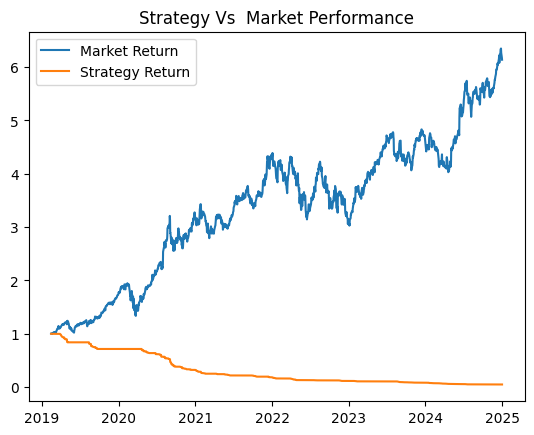

In [49]:
plt.figure()
plt.plot(ap_data.index, 
         ap_data['Cumulative_Market_Return'],label='Market Return')
plt.plot(ap_data.index,
         ap_data['Cumulative_Strategy_Return'],label='Strategy Return')
plt.legend()

plt.title("Strategy Vs  Market Performance")

plt.show()

In [34]:
ap_data.to_csv("../data/day_7.csv")

In [50]:
ap_data[['Returns','Strategy_Return','Recommendation']].head()

,Returns,Strategy_Return,Recommendation
Date,,,
2019-02-14,0.003643,0.0,Hold
2019-02-15,-0.002225,0.0,Hold
2019-02-19,0.002992,0.0,Hold
2019-02-20,0.006435,0.0,Hold
2019-02-21,-0.005639,0.0,Hold


In [39]:
ap_data['Recommendation'].value_counts()


Recommendation
Hold    1244
Buy      128
Sell     108
Name: count, dtype: int64

In [53]:
print(ap_data['Strategy_Return'].describe())
print(ap_data['Cumulative_Strategy_Return'].iloc[-1])

count    1480.000000
mean       -0.001991
std         0.006564
min        -0.080061
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: Strategy_Return, dtype: float64
0.05068373674156657


In [ ]:
ap_data[ap_data['Recommendation'] == 'Buy' ][['Returns','Strategy_Return']].head(20)

In [55]:
ap_data['Recommendation_Shifted'] = ap_data['Recommendation'].shift(1)

In [ ]:
ap_data

In [67]:
def strategy_return(x):
    if x['Recommendation_Shifted'] == 'Buy' : 
        return  x['Returns']
    elif x['Recommendation_Shifted'] == 'Sell' : 
        return  -x['Returns']
    else :
        return 0
    
ap_data['Strategy_Return'] = ap_data.apply(strategy_return,axis=1)

ap_data[['Strategy_Return','Recommendation','Returns']].head(120)

ap_data['Strategy_Return'].value_counts()
    



Strategy_Return
 0.000000    1244
-0.009393       1
 0.011870       1
 0.012971       1
 0.014661       1
             ... 
-0.001395       1
 0.016227       1
-0.013731       1
 0.005427       1
-0.013771       1
Name: count, Length: 237, dtype: int64

In [68]:
ap_data['Cumulative_Strategy_Return'] = ( 1 + ap_data['Strategy_Return']).cumprod()

In [69]:
ap_data['Cumulative_Strategy_Return'].iloc[-1]

1.1114626316166145

In [70]:
print(ap_data['Recommendation_Shifted'].value_counts())
print('\n')
print(ap_data['Strategy_Return'].describe())
print('\n')
print(ap_data['Cumulative_Strategy_Return'].iloc[-1])

Recommendation_Shifted
Hold    1243
Buy      128
Sell     108
Name: count, dtype: int64


count    1480.000000
mean        0.000093
std         0.006543
min        -0.080061
25%         0.000000
50%         0.000000
75%         0.000000
max         0.040857
Name: Strategy_Return, dtype: float64


1.1114626316166145


In [66]:
ap_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Rolling Mean',
       'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation', 'Strategy_Return', 'Cumulative_Strategy_Return',
       'Cumulative_Market_Return', 'Recommendation_Shifted'],
      dtype='object')

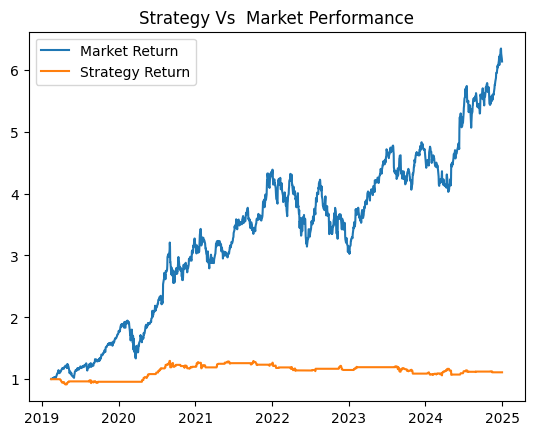

In [ ]:
plt.figure()
plt.plot(ap_data.index, 
         ap_data['Cumulative_Market_Return'],label='Market Return')
plt.plot(ap_data.index,
         ap_data['Cumulative_Strategy_Return'],label='Strategy Return')

plt.legend() # name 

plt.title("Strategy Vs  Market Performance")

plt.show()

In [72]:
ap_data.to_csv("../data/day_7.csv")

In [73]:
ap_data['Cumulative_Market_Return']

Date
2019-02-14    1.003643
2019-02-15    1.001410
2019-02-19    1.004407
2019-02-20    1.010871
2019-02-21    1.005171
                ...   
2024-12-24    6.326826
2024-12-26    6.346918
2024-12-27    6.262871
2024-12-30    6.179804
2024-12-31    6.136188
Name: Cumulative_Market_Return, Length: 1480, dtype: float64